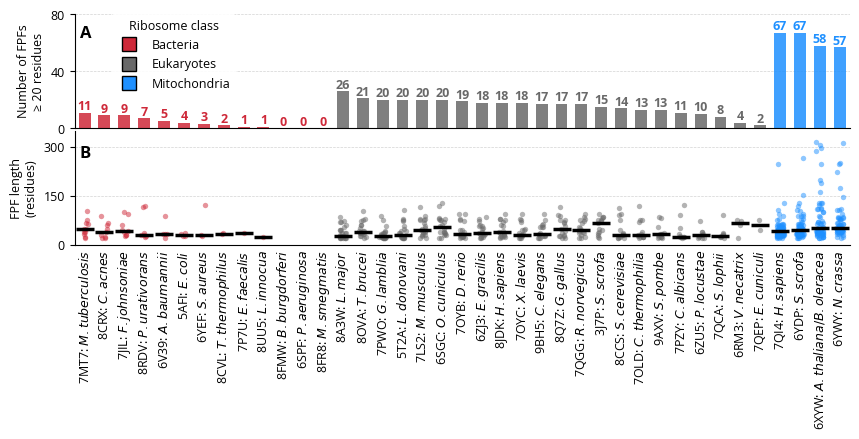

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib

matplotlib.rcParams["font.size"] = 9
matplotlib.rcParams["font.family"] = "Open Sans"

BASE_DIR = ".."
PLOT_DIR = f"{BASE_DIR}/PLOTS"

RIBOSOME_CLASS_COLORS = {
    "bacteria": "#CE2939",
    "eukaryotes": "#696969",
    "mitochondria": "#1E90FF",
}

MIN_LENGTH = 20

with open(f"{BASE_DIR}/ribosome_info.json") as f:
    ribosome_info = json.load(f)

with open(f"{BASE_DIR}/fpf_info.json") as f:
    fpf_info = json.load(f)

ribo_dict = {entry["pdb_id"].upper(): entry for entry in ribosome_info}

ribosome_data = []
for entry in ribosome_info:
    pdb_id = entry["pdb_id"].upper()
    ribosome_class = entry["ribosome_class"]

    fragments = fpf_info.get(pdb_id, [])
    lengths = [frag["length"] for frag in fragments if frag["length"] >= MIN_LENGTH]

    ribosome_data.append({
        "pdb_id": pdb_id,
        "organism": entry["organism"],
        "ribosome_class": ribosome_class,
        "count": len(lengths),
        "lengths": lengths,
        "median_length": np.median(lengths) if lengths else 0,
    })

class_max_count = {}
for rd in ribosome_data:
    rc = rd["ribosome_class"]
    class_max_count[rc] = max(class_max_count.get(rc, 0), rd["count"])

ribosome_class_order = sorted(class_max_count, key=lambda rc: class_max_count[rc], reverse=True)

ribosome_data.sort(
    key=lambda x: (ribosome_class_order.index(x["ribosome_class"]), x["count"]),
    reverse=True
)

labels = [f"{rd['pdb_id']}: $\\mathit{{{rd['organism']}}}$" for rd in ribosome_data]
colors = [RIBOSOME_CLASS_COLORS[rd["ribosome_class"]] for rd in ribosome_data]
counts = [rd["count"] for rd in ribosome_data]
lengths_per_ribosome = [rd["lengths"] for rd in ribosome_data]
medians = [rd["median_length"] for rd in ribosome_data]
n = len(ribosome_data)
x = np.arange(n)

fig = plt.figure(figsize=(10, 3))
gs = gridspec.GridSpec(2, 1, figure=fig, hspace=0.02)
ax_top = fig.add_subplot(gs[0])
ax_bot = fig.add_subplot(gs[1], sharex=ax_top)

bars = ax_top.bar(x, counts, width=0.6, color=colors, alpha=0.85, zorder=2)
for bar, count, color in zip(bars, counts, colors):
    ax_top.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.15,
        str(count),
        va="bottom", ha="center",
        color=color, fontweight="bold"
    )

ax_top.set_ylabel("Number of FPFs\n≥ 20 residues")
ax_top.set_ylim(0, max(counts) * 1.2 if counts else 1)
ax_top.set_xlim(-0.5, n - 0.5)
ax_top.set_yticks([0, 40, 80])

ax_top.spines["top"].set_visible(False)
ax_top.spines["right"].set_visible(False)
ax_top.tick_params(axis="x", length=0)
plt.setp(ax_top.get_xticklabels(), visible=False)

ax_top.yaxis.grid(True, linestyle="--", linewidth=0.5, color="lightgray", zorder=0)

np.random.seed(0)
for i, (lengths, median, color) in enumerate(zip(lengths_per_ribosome, medians, colors)):
    if not lengths:
        continue
    jitter = np.random.uniform(-0.18, 0.18, size=len(lengths))
    ax_bot.scatter(
        np.array([i] * len(lengths)) + jitter,
        lengths,
        color=color, alpha=0.5, s=15, zorder=3, linewidths=0,
    )
    ax_bot.scatter(
        i, median,
        color="black", marker="_", s=150, linewidths=2.5, zorder=4,
    )

ax_bot.set_ylabel("FPF length\n(residues)")
ax_bot.set_ylim(0, 350)
ax_bot.set_yticks([0, 150, 300])

ax_bot.set_xticks(x)
ax_bot.set_xticklabels(labels, rotation=90)

ax_bot.spines["top"].set_visible(False)
ax_bot.spines["right"].set_visible(False)
ax_bot.tick_params(axis="x", length=0)

ribosome_class_handles = [
    plt.Line2D([0], [0], marker="s", color="none",
               markerfacecolor=RIBOSOME_CLASS_COLORS[rc], markersize=10,
               label=rc.capitalize())
    for rc in ribosome_class_order[::-1]
]
ax_top.legend(
    handles=ribosome_class_handles,
    title="Ribosome class",
    loc="upper left",
    framealpha=0.9,
    bbox_to_anchor=(0.04, 1.05),
    edgecolor="none"
)
ax_bot.yaxis.grid(True, linestyle="--", linewidth=0.5, color="lightgray", zorder=0)

fig.text(0.13, 0.8, "A", fontweight="bold", fontsize=12)
fig.text(0.13, 0.4, "B", fontweight="bold", fontsize=12)

plt.savefig(f"{PLOT_DIR}/fpfs.png", dpi=300, bbox_inches="tight")